# Download and prepare `RH` (2004-2025)

**notebook version**: `3` (20 Jul 2026)


## ℹ️ About this notebook

Downloads screened relative humidity `RH` from the InfluxDB database, merges the data sources into
one continuous series, corrects the August 2012 logger timestamp shift, removes the three damaged
2012 periods, applies the `RH > 100%` offset correction, then fills every gap in two reconstruction
passes — first from the co-located NABEL sensor, then from MeteoSwiss Lägern for the gaps NABEL
cannot reach — and stores the result to the external data folder.

This notebook follows notebooks `01` (`SW_IN`), `02` (`TA`) and `03` (`PPFD_IN`) up to and
including the corrections.

::: {.callout-important title="What this notebook does and does not do"}
It **reconstructs** missing `RH_T1_47_1`, it does not model it: each gap is filled from another
measurement of the same quantity, offset-corrected month by month. There is no XGBoost model, no
meteorological drivers, no feature engineering.

Two sources, in order of preference. **NABEL at 49 m** (same tower, 2004-2018) is the closer,
stronger reference and fills first (flag `3`). **MeteoSwiss Lägern at 2.5 km** (2004-2025) fills
the rest — chiefly the post-2018 gaps NABEL cannot reach (flag `4`). Lägern is 2.5 km away and
400 m lower, so a flag `4` value carries larger uncertainty than a flag `3` one: a weaker
reconstruction, still not a measurement.

The exported series is now **complete** — every record carries a value. Earlier versions left ~920
post-2018 records as `NaN`; the Lägern pass fills them.
:::

**Output columns:**

- `RH_T1_47_1` — the corrected, gap-free series (%)
- `FLAG_RH_T1_47_1_MISSING` — where each record comes from; `0` = measured at 47 m, `3` =
  reconstructed from NABEL (49 m), `4` = reconstructed from MeteoSwiss Lägern (2.5 km). Codes `1`
  (never measured) and `2` (removed as faulty) remain in the legend but no longer occur
  (see `FLAG_LEGEND` below)

The flag deliberately does **not** reuse the `ISFILLED` vocabulary of `01`-`03`, whose codes
describe *which model* produced a value. Nothing here is modelled. A consumer wanting only genuine
47 m measurements filters `flag == 0`; one wanting every usable value takes all records.

Downloading uses diive's in-house InfluxDB engine `InfluxIO`. It needs `influxdb-client`, which
a plain `uv sync` installs here via the `diive[db]` extra.


***

## 📇 Data sources

**Series**

- `RH_T1_47_1` — ETH, 47 m. **This is the product series.** mst (2004-2021), diive (2022-2025)
- `RH_NABEL_T1_49_1` — NABEL, 49 m, same tower, 2004-2018. Independent reference for the 2012
  diagnostics below, and the **first** reconstruction source. Not exported.
- `RH_LAE_MS` — MeteoSwiss Lägern, 2.5 km, 845 m, 2004-2025. The **second** reconstruction source,
  for the post-2018 gaps NABEL cannot reach. Read from the product written by
  `10_REFERENCE/MeteoSwiss_LAE_2004-2025.ipynb`. Not exported.

NABEL sits on a separate acquisition system, which is what lets it detect a logger fault on the
ETH side. Both references reconstruct `RH_T1_47_1` where that sensor has no value; neither is
itself exported.

**Legend**

- NABEL ... Data from [NABEL](https://www.bafu.admin.ch/bafu/en/home/topics/air/luftbelastung/national-air-pollution-monitoring-network--nabel-.html), meteoscreening with [diive](https://github.com/holukas/diive)
- mst ... Data from ETH, meteoscreening with the now deprecated MeteoscreeningTool
- diive ... Data from ETH, meteoscreening with diive


## ⏱️ Timestamp convention

The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`**. On download, `InfluxIO`
shifts the UTC timestamp by `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the returned data are in **local
time** (UTC + offset) and still `TIMESTAMP_END`. `TimestampSanitizer(output_middle_timestamp=True)`
then converts to `TIMESTAMP_MID`, which is what the rest of this notebook works with.

`START` and `STOP` are interpreted in the same timezone as `TIMEZONE_OFFSET_TO_UTC_HOURS`.

***

## ⚙️ Settings


### Data settings


In [1]:
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # Timezone, e.g. "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'  # Expected resolution; TimestampSanitizer raises if the data disagree
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

TARGET = 'RH_T1_47_1'           # exported variable
REFERENCE = 'RH_NABEL_T1_49_1'  # independent sensor: 2012 diagnostics + reconstruction source

# Reconstruction of TARGET from REFERENCE. The additive per-month offset between the two sensors
# is fitted on the overlap within +/- OFFSET_WINDOW_YEARS calendar years of the record being
# reconstructed, because that offset drifts substantially over the record (see the
# reconstruction section). A month with fewer than OFFSET_MIN_SAMPLES local samples falls back
# to the offset pooled over the whole overlap.
OFFSET_WINDOW_YEARS = 2
OFFSET_MIN_SAMPLES = 500

# Output: data files live in the external (untracked) data folder, with the same
# numeric prefix as this notebook.
OUTNAME = "04_METEO_RH_CORRECTED_2004-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

# Second reconstruction source: MeteoSwiss Lägern, 2.5 km from the tower, for the post-2018
# gaps the NABEL sensor cannot reach. Produced by 10_REFERENCE/MeteoSwiss_LAE_2004-2025.ipynb
# and addressed by path, so a move breaks this read.
REFPATH = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
           r"\workflow\10_METEO\10_REFERENCE\MeteoSwiss_LAE_30MIN_2004-2025.parquet")
REFCOL = "RH_LAE_MS"


### Imports


In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv
from diive.core.io.db.influx import InfluxIO  # diive's in-house InfluxDB engine (via the diive[db] extra)
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

# Start time is kept so the last cell can report the total runtime of the notebook.
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-07-21 00:55:52
diive version: v0.91.0


In [3]:
# Provenance flag used in this notebook. This is NOT the ISFILLED flag of notebooks 01-03, whose
# codes name the model that produced a value; nothing here is modelled.
#
# Codes 0, 3 and 4 carry a value, codes 1 and 2 are gaps:
#   filter flag == 0           for genuine 47 m measurements only
#   filter flag in (0, 3, 4)   for every usable value
#
# 1 and 2 stay separated so a downstream fill can tell an instrument that never delivered a value
# from a value this notebook judged faulty and threw away. In this record both references together
# cover every gap, so 1 and 2 no longer occur, but they are kept in the vocabulary.
FLAG_LEGEND = {
    0: '0 = measured at 47 m (corrected)',
    1: '1 = missing, never measured',
    2: '2 = missing, removed here as faulty (2012 damaged periods)',
    3: '3 = reconstructed from NABEL at 49 m',
    4: '4 = reconstructed from MeteoSwiss Lägern at 2.5 km',
}
PRESENT_FLAGS = (0, 3, 4)  # codes that carry a value


### Helper functions


The plot helpers of notebooks `01` and `03` split a series by a gap-filling flag. There is no
such flag here, so the equivalents below split by *presence* instead: measured against missing,
and within missing, never-measured against removed-here.

In [4]:
def remove_rh_offset_by_year(series: pd.Series, showplot: bool = False):
    """Apply diive's `RH > 100%` offset correction within each year that contains a value > 100%.

    `dv.corrections.remove_relativehumidity_offset` derives a daily offset from the records that
    exceed 100%, then **interpolates and ffill/bfills that offset over the whole index**. Called
    once on the full record that also shifts years which never exceed 100%: measured here, a flat
    +0.71 % over 2004-2006 (bfilled from 2007) and a flat +0.133 % over 2016-2025 (ffilled from
    2015), neither of which has any exceedance to justify it.

    Subtracting the offset from records below 100% is the point of the correction — a sensor
    reading 102 when the true value is 100 is biased across its whole range, not only at
    saturation. Extrapolating that bias into a decade with no evidence of drift is not. Running
    the correction per exceedance year keeps the first and drops the second, and leaves every
    other year bit-identical to the input.

    Note the library function renames the series it is given in place, so it gets a copy.

    Returns (corrected series, list of years the correction ran in).
    """
    out = series.copy()
    years = sorted({int(y) for y in series.index.year[series > 100]})
    for year in years:
        locs = series.index.year == year
        out.loc[locs] = dv.corrections.remove_relativehumidity_offset(
            series.loc[locs].copy(), showplot=showplot)
    return out, years


def monthly_offset_table(target: pd.Series, reference: pd.Series,
                         window_years: int = None, min_samples: int = None) -> pd.Series:
    """Additive offset `target - reference` per (year, month), fitted on a local year window.

    The two sensors do not differ by a constant. The offset is strongly seasonal (about +3.9 % in
    February against +0.4 % in August) and it drifts across the record (annual mean +0.08 % in
    2006 against +5.06 % in 2017). A single offset pooled over the whole overlap therefore
    mis-corrects both ends: it would apply +3.42 % to January 2004, where the local evidence
    says +1.35 %.

    For every year it fits each month on the overlap within +/- `window_years` calendar years.
    A month with fewer than `min_samples` local records falls back to the offset pooled over the
    whole overlap, and a month absent from the overlap entirely falls back to the pooled mean.

    Returns a Series indexed by (year, month).
    """
    window_years = OFFSET_WINDOW_YEARS if window_years is None else window_years
    min_samples = OFFSET_MIN_SAMPLES if min_samples is None else min_samples

    overlap = pd.concat([target.rename('t'), reference.rename('r')], axis=1).dropna()
    diff = overlap.t - overlap.r
    pooled_monthly = diff.groupby(diff.index.month).mean()
    pooled_mean = float(diff.mean())

    rows = {}
    for year in range(int(target.index.year.min()), int(target.index.year.max()) + 1):
        near = diff[(diff.index.year >= year - window_years) &
                    (diff.index.year <= year + window_years)]
        grouped = near.groupby(near.index.month)
        local_mean, local_n = grouped.mean(), grouped.size()
        for month in range(1, 13):
            if month in local_mean.index and local_n.get(month, 0) >= min_samples:
                rows[(year, month)] = float(local_mean[month])
            elif month in pooled_monthly.index:
                rows[(year, month)] = float(pooled_monthly[month])
            else:
                rows[(year, month)] = pooled_mean
    return pd.Series(rows).rename('offset')


def reconstruct_from_reference(target: pd.Series, reference: pd.Series, offsets: pd.Series):
    """Fill gaps in `target` with offset-corrected `reference` values, clipped to [0, 100].

    Only records where `target` is missing AND `reference` has a value are touched; everything
    else comes back untouched. Returns (reconstructed series, boolean mask of what was filled).
    """
    filled = target.isna() & reference.notna()
    keys = pd.MultiIndex.from_arrays([target.index[filled].year, target.index[filled].month])
    applied = offsets.reindex(keys).values
    if np.isnan(applied).any():
        raise ValueError("no offset available for some records to reconstruct")

    out = target.copy()
    out.loc[filled] = np.clip(reference.loc[filled].values + applied, 0, 100)
    return out, filled


def plot_presence_panels(series, flag, title, ylabel='RH (%)', figsize=(16, 8)):
    """Four stacked panels: the exported series, then each provenance class on its own.

    The lower panels are the ones to look at. Each class is drawn against a blank background, so
    a block of reconstructed records sitting at the wrong level, or a gap class turning up where
    it should not, is visible instead of hidden under the measured series.
    """
    _plotdf = pd.DataFrame({
        'RH (all values)': series,
        'measured at 47 m': series.where(flag == 0),
        'reconstructed from NABEL (49 m)': series.where(flag == 3),
        'reconstructed from Lägern (2.5 km)': series.where(flag == 4),
        'missing (never measured / removed)': flag.where(flag.isin([1, 2])),
    })
    axs = _plotdf.plot(subplots=True, figsize=figsize, x_compat=True, alpha=.9,
                       title=title, legend=True)
    for ax in axs[:4]:
        ax.set_ylabel(ylabel)
    axs[4].set_ylabel('flag')
    plt.tight_layout()
    return axs


def coverage_stats_by_year(series, flag, legend=None):
    """Records per year by provenance class.

    Deliberately reports counts, not a "measured %" headline: this product is incomplete by
    design and a single completeness figure invites it to be read as a gap-filled series.
    """
    legend = legend or FLAG_LEGEND
    tab = (pd.crosstab(flag.index.year, flag)
             .rename(columns=lambda f: legend.get(f, f))
             .rename_axis(index='year', columns=None))
    tab.insert(0, 'records', series.groupby(series.index.year).size())
    nonmeasured = tab.drop(columns=['records'] + [c for c in tab.columns if str(c).startswith('0 =')],
                           errors='ignore')
    if not nonmeasured.empty and nonmeasured.to_numpy().sum() > 0:
        ax = nonmeasured.plot(kind='bar', stacked=True, figsize=(14, 4),
                              title='Non-measured records per year, by provenance')
        ax.set_ylabel('records')
        ax.legend(fontsize=8)
        plt.tight_layout()
    return tab

### 🔌 Connect to database


In [5]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

***

## ⬇️ `NABEL` and ETH data from `diive` meteoscreening


### Download


In [6]:
%%time

BUCKET = f'ch-lae_processed'
FIELDS = ['RH_NABEL_T1_49_1', 'RH_T1_47_1']
MEASUREMENTS = ['RH']
START = '2004-01-01 00:00:01'
STOP = '2026-01-01 00:00:01'
DATA_VERSION = 'meteoscreening_diive'

nabel_eth_diive_rh, _, _ = dbc.download(
    bucket=BUCKET,
    measurements=MEASUREMENTS,
    fields=FIELDS,
    start=START,  # Download data starting with this date (the start date itself IS included),
    stop=STOP,  # Download data before this date (the stop date itself IS NOT included),
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION
)

> DOWNLOADING from bucket ch-lae_processed: variables ['RH_NABEL_T1_49_1', 'RH_T1_47_1'] from 
measurements ['RH'], data version ['meteoscreening_diive'], between 2004-01-01 00:00:01 and 
2026-01-01 00:00:01 (timezone offset to UTC 1)

> Downloaded data for 2 variables:

CPU times: total: 5.75 s
Wall time: 9.04 s


In [7]:
nabel_eth_diive_rh

,RH_T1_47_1,RH_NABEL_T1_49_1
TIMESTAMP_END,,
2004-01-01 00:30:00,NaN,96.366667
2004-01-01 01:00:00,NaN,95.566667
2004-01-01 01:30:00,NaN,92.200000
2004-01-01 02:00:00,NaN,91.300000
2004-01-01 02:30:00,NaN,92.633333
...,...,...
2025-12-31 22:00:00,42.332976,NaN
2025-12-31 22:30:00,39.230344,NaN
2025-12-31 23:00:00,55.771803,NaN


### Sanitize timestamp


In [8]:
nabel_eth_diive_rh = TimestampSanitizer(
    data=nabel_eth_diive_rh,
    output_middle_timestamp=True,
    nominal_freq=REQUIRED_TIME_RESOLUTION,  # raises ValueError if the data are not 30MIN
).get()
nabel_eth_diive_rh

,RH_T1_47_1,RH_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,96.366667
2004-01-01 00:45:00,NaN,95.566667
2004-01-01 01:15:00,NaN,92.200000
2004-01-01 01:45:00,NaN,91.300000
2004-01-01 02:15:00,NaN,92.633333
...,...,...
2025-12-31 21:45:00,42.332976,NaN
2025-12-31 22:15:00,39.230344,NaN
2025-12-31 22:45:00,55.771803,NaN


***

## ⬇️ Data from `mst` meteoscreening


### Download


In [9]:
%%time

BUCKET = f'ch-lae_processed'
FIELDS = ['RH_T1_47_1']
MEASUREMENTS = ['RH']
START = '2004-01-01 00:00:01'
STOP = '2022-01-01 00:00:01'
DATA_VERSION = 'meteoscreening_mst'

mst_rh, _, _ = dbc.download(
    bucket=BUCKET,
    measurements=MEASUREMENTS,
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION
)

> DOWNLOADING from bucket ch-lae_processed: variables ['RH_T1_47_1'] from measurements ['RH'], 
data version ['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2022-01-01 00:00:01 (timezone 
offset to UTC 1)

> Downloaded data for 1 variables:

CPU times: total: 5 s
Wall time: 7.33 s


In [10]:
mst_rh

,RH_T1_47_1
TIMESTAMP_END,
2004-09-20 11:00:00,81.199997
2004-09-20 11:30:00,78.199997
2004-09-20 12:00:00,76.500000
2004-09-20 12:30:00,72.199997
2004-09-20 13:00:00,73.400002
...,...
2021-12-31 22:00:00,94.843261
2021-12-31 22:30:00,93.992424
2021-12-31 23:00:00,95.821067


### Sanitize timestamp


In [11]:
mst_rh = TimestampSanitizer(
    data=mst_rh,
    output_middle_timestamp=True,
    nominal_freq=REQUIRED_TIME_RESOLUTION,
).get()
mst_rh

,RH_T1_47_1
TIMESTAMP_MIDDLE,
2004-09-20 10:45:00,81.199997
2004-09-20 11:15:00,78.199997
2004-09-20 11:45:00,76.500000
2004-09-20 12:15:00,72.199997
2004-09-20 12:45:00,73.400002
...,...
2021-12-31 21:45:00,94.843261
2021-12-31 22:15:00,93.992424
2021-12-31 22:45:00,95.821067


***

## ❇️ Merge data


Data from `diive` meteoscreening are the main data, remaining gaps are filled in from the `mst`
meteoscreening. Note this is a merge of two *screenings of the same measurement*, not a gap-fill:
no value is modelled, every value still comes from the instrument.

In [12]:
rh_2004_2025 = nabel_eth_diive_rh.copy()

for col in [TARGET, REFERENCE]:
    if col in mst_rh.columns:
        before = rh_2004_2025[col].notna().sum()
        rh_2004_2025[col] = rh_2004_2025[col].combine_first(mst_rh[col])
        after = rh_2004_2025[col].notna().sum()
        print(f"{col}: {before:,} -> {after:,} records ({after - before:,} added from mst)")

rh_2004_2025

RH_T1_47_1: 70,012 -> 370,294 records (300,282 added from mst)


,RH_T1_47_1,RH_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,96.366667
2004-01-01 00:45:00,NaN,95.566667
2004-01-01 01:15:00,NaN,92.200000
2004-01-01 01:45:00,NaN,91.300000
2004-01-01 02:15:00,NaN,92.633333
...,...,...
2025-12-31 21:45:00,42.332976,NaN
2025-12-31 22:15:00,39.230344,NaN
2025-12-31 22:45:00,55.771803,NaN


### Sanitize timestamp


In [13]:
rh_2004_2025 = TimestampSanitizer(data=rh_2004_2025, output_middle_timestamp=True).get()
rh_2004_2025

,RH_T1_47_1,RH_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,96.366667
2004-01-01 00:45:00,NaN,95.566667
2004-01-01 01:15:00,NaN,92.200000
2004-01-01 01:45:00,NaN,91.300000
2004-01-01 02:15:00,NaN,92.633333
...,...,...
2025-12-31 21:45:00,42.332976,NaN
2025-12-31 22:15:00,39.230344,NaN
2025-12-31 22:45:00,55.771803,NaN


### Record start


`RH_T1_47_1` does not start at the beginning of 2004. The cell below reports the first
measured timestamp of each sensor, so the short first year further down is not mistaken for a
data loss.

In [14]:
for col in [TARGET, REFERENCE]:
    s = rh_2004_2025[col]
    print(f"{col:20s} first {s.first_valid_index()}   last {s.last_valid_index()}   "
          f"measured {s.notna().sum():,}")

RH_T1_47_1           first 2004-09-20 10:45:00   last 2025-12-31 23:45:00   measured 370,294
RH_NABEL_T1_49_1     first 2004-01-01 00:15:00   last 2018-12-31 23:45:00   measured 262,314


### Heatmap


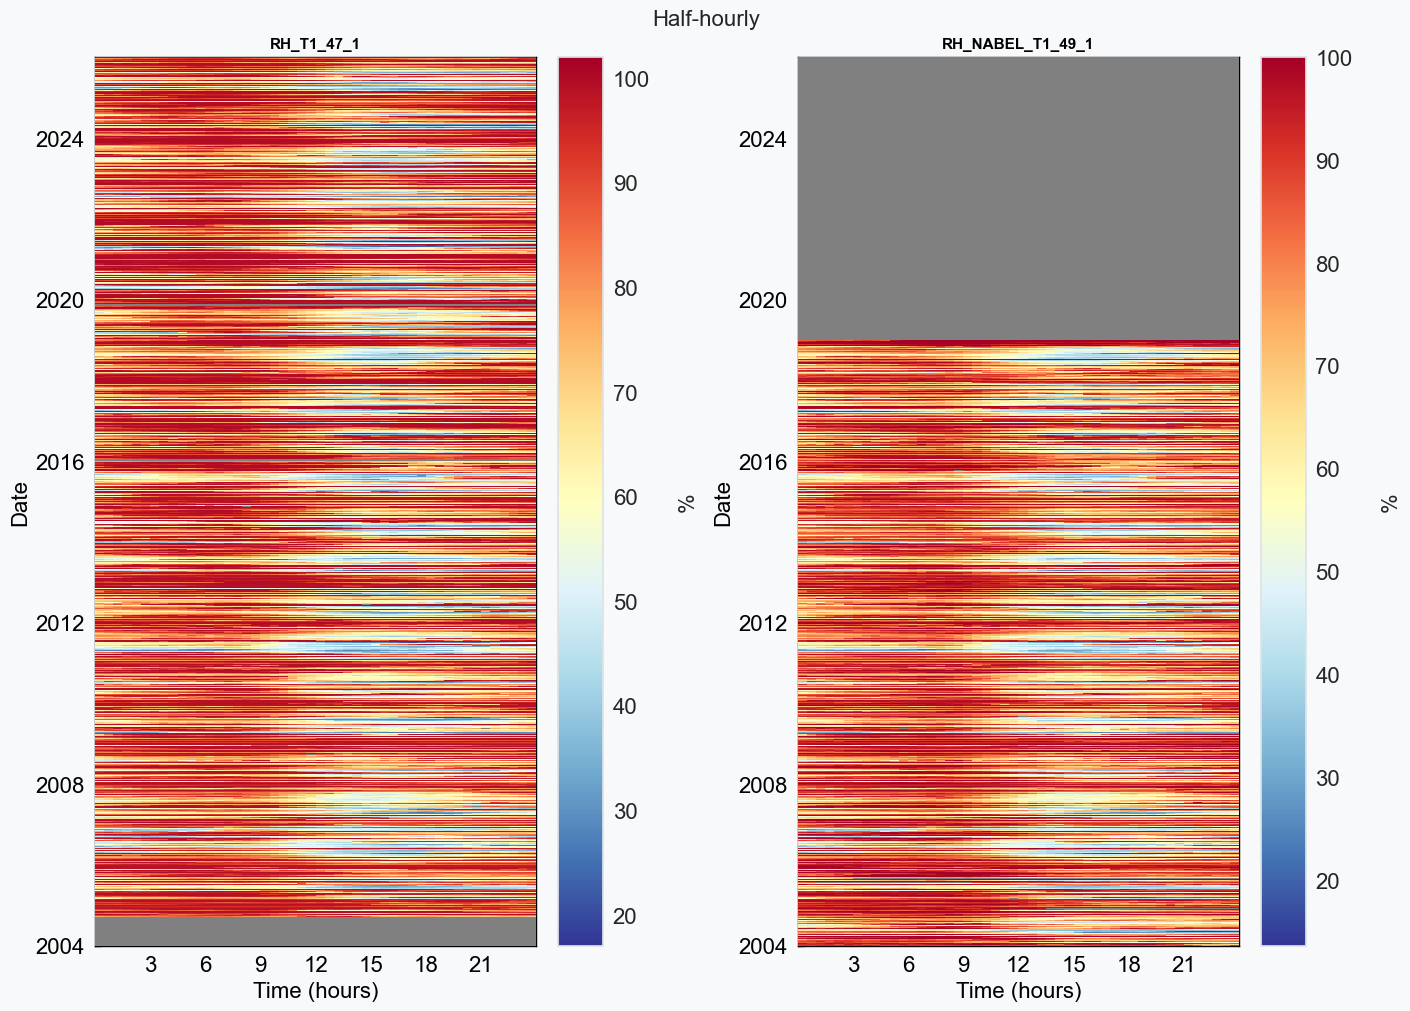

In [15]:
fig, axs = plt.subplots(ncols=2, figsize=(14, 10), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.plotting.HeatmapDateTime(series=rh_2004_2025[TARGET]).plot(
    ax=axs[0], cb_digits_after_comma=0, zlabel='%',
    format_style=dv.plotting.FormatStyle(title=TARGET, title_fontsize=11))
dv.plotting.HeatmapDateTime(series=rh_2004_2025[REFERENCE]).plot(
    ax=axs[1], cb_digits_after_comma=0, zlabel='%',
    format_style=dv.plotting.FormatStyle(title=REFERENCE, title_fontsize=11))

***

## ✴️ Corrections


### Order of the correction steps

The three steps below run in a fixed order, and the order matters:

1. **Timestamp shift** (August 2012). It moves records along the time axis, so every window
   defined afterwards refers to the corrected axis.
2. **Removal of the three damaged 2012 periods.** These records are faulty, and some of them
   read above 100%.
3. **`RH > 100%` offset correction.** It derives its offset from the daily mean of the records
   that exceed 100%, so it must not see the faulty ones. Running step 3 before step 2 would let
   damaged records set the offset that is then subtracted from good data on neighbouring days.
   The cell in step 2 reports how many of the removed records exceeded 100%.

Two reconstruction passes — **from NABEL, then from MeteoSwiss Lägern** — run after all three in
their own sections below. They must come last: they fill gaps, so everything that creates or
repairs a gap has to have happened first, and the offsets they fit between the sensors have to be
fitted on *corrected* 47 m data.

Steps 2 and 3 both need care around gaps, for opposite reasons. Step 2 *creates* gaps and their
provenance has to be recorded before step 3 runs. Step 3 is checked below to confirm it does not
*write into* gaps — the correction in notebook `03` does exactly that.

### Timestamp shift in August 2012
**Info from fieldbook entry 17 Aug 2012:**
>   adjusted the logger date and time. On Servertime (Computer System Time) 17.08.2012 12:31.42 the loggertime was 16.08.2012 08:06:00. Synchronized time at 17.08.2012 11:40:00 servertime. The logger data aquisition on the moxa embedded was restarted

This is a clock error of the logger, so it affects every variable that logger recorded. The same
correction as in notebooks `01`-`03` is applied here to `RH_T1_47_1`.

**Verified for `RH` rather than assumed.** Aligning `RH_T1_47_1` against the independent NABEL
sensor day by day and searching for the lag that agrees best (baseline agreement between the two
sensors in August is about 2.0 %, see the monthly table further down):

| date | best lag | RMSE at best lag | RMSE at zero lag |
|---|---|---|---|
| 2012-08-08 | -38.0 h | 16.49 | 21.78 |
| 2012-08-09 | +16.0 h | 5.61 | 13.54 |
| **2012-08-10** | **+15.5 h** | **1.13** | 11.38 |
| **2012-08-11** | **+15.5 h** | **1.56** | 13.88 |
| **2012-08-12** | **+15.5 h** | **2.23** | 26.30 |
| **2012-08-13** | **+15.5 h** | **2.13** | 25.01 |
| **2012-08-14** | **+15.5 h** | **1.20** | 18.57 |
| **2012-08-15** | **+15.5 h** | **3.37** | 37.26 |
| **2012-08-16** | **+15.5 h** | **1.68** | 21.57 |
| 2012-08-17 | 0 | 1.06 | 1.06 |

10 to 16 August lock onto `+15.5 h` and the error collapses from 11-37 % to 1.1-3.4 %, back inside
the normal agreement band. That is the signature of a genuine clock offset, and it is the same
`+15.5 h` found for `SW_IN`, `TA` and `PPFD_IN`. After the shift is applied, the same day-by-day
search over 10-19 August returns a best lag of 0 with RMSE 0.75-3.18, i.e. nothing left to repair.

The heatmaps below show the diurnal pattern before and after. `RH` peaks at night and dips in the
afternoon, so the visual check is the inverse of the temperature one: after the correction the
*moist* band has to sit around the night again.

RH_T1_47_1: 376 records moved +15.5 h, last shifted timestamp 2012-08-17 11:15:00


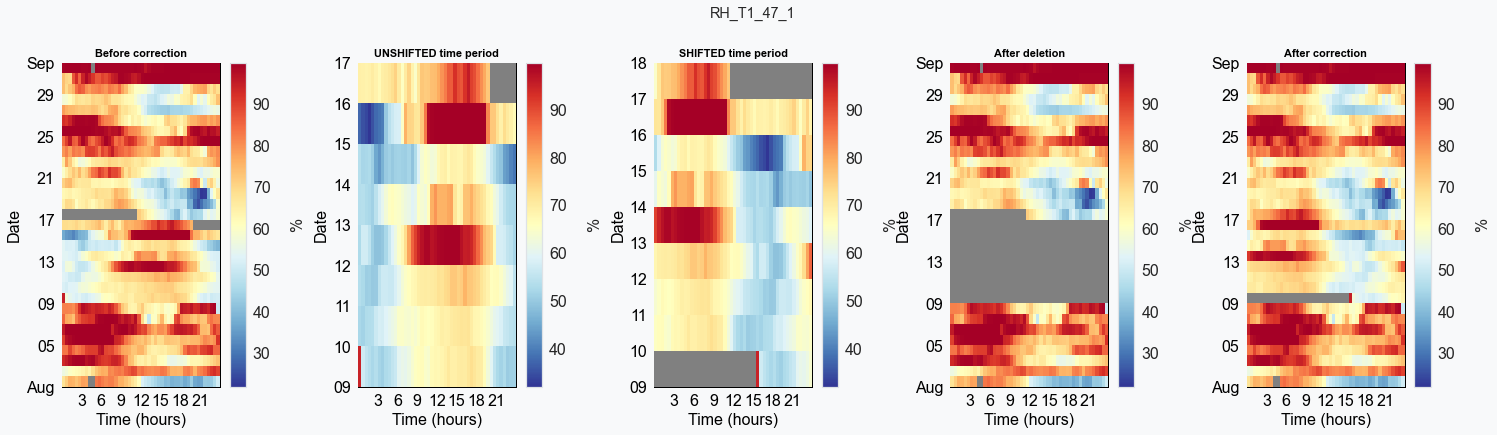

In [16]:
AFFECTED_VARS = [TARGET]
_df = rh_2004_2025.copy()

for av in AFFECTED_VARS:
    fig = plt.figure(figsize=(24, 6), dpi=72)
    fig.suptitle(f"{av}")
    gs = gridspec.GridSpec(1, 5)  # rows, cols
    gs.update(wspace=0.5, hspace=1, left=.1, right=.9, top=.85, bottom=.1)
    ax_before = fig.add_subplot(gs[0, 0])
    ax_unshifted = fig.add_subplot(gs[0, 1])
    ax_shifted = fig.add_subplot(gs[0, 2])
    ax_after = fig.add_subplot(gs[0, 3])
    ax_corrected = fig.add_subplot(gs[0, 4])

    # Show time period around issue, before correction
    _show_locs = (_df.index >= '2012-08-01 00:00') & (_df.index <= '2012-09-01 00:00')
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_before, cb_digits_after_comma=0, zlabel='%',
        format_style=dv.plotting.FormatStyle(title="Before correction", title_fontsize=11))

    # Get shifted time period
    _series_corrected = _df.loc[_show_locs, av].copy()
    # Identify shifted time period
    ISSUE_START = '2012-08-09 00:00'
    ISSUE_END = '2012-08-17 00:00'
    _shifted_locs = (_df.index >= ISSUE_START) & (_df.index <= ISSUE_END)
    _series_shifted = _df.loc[_shifted_locs, av].copy()
    _series_shifted = _series_shifted.dropna()
    dv.plotting.HeatmapDateTime(series=_series_shifted).plot(
        ax=ax_unshifted, cb_digits_after_comma=0, zlabel='%',
        format_style=dv.plotting.FormatStyle(title="UNSHIFTED time period", title_fontsize=11))

    # Shift by 15.5 hours during shifted time period, create corrected time series
    _series_shifted.index = _series_shifted.index + pd.Timedelta(hours=15.5)
    dv.plotting.HeatmapDateTime(series=_series_shifted).plot(
        ax=ax_shifted, cb_digits_after_comma=0, zlabel='%',
        format_style=dv.plotting.FormatStyle(title="SHIFTED time period", title_fontsize=11))

    # Delete data between start of issue and the last timestamp of shifted data
    _overwrite_locs = (_df.index >= ISSUE_START) & (_df.index <= _series_shifted.index[-1])
    _df.loc[_overwrite_locs, av] = np.nan
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_after, cb_digits_after_comma=0, zlabel='%',
        format_style=dv.plotting.FormatStyle(title="After deletion", title_fontsize=11))

    # Fill in corrected values
    _df.loc[_overwrite_locs, av] = _series_shifted
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_corrected, cb_digits_after_comma=0, zlabel='%',
        format_style=dv.plotting.FormatStyle(title="After correction", title_fontsize=11))

    print(f"{av}: {len(_series_shifted)} records moved +15.5 h, "
          f"last shifted timestamp {_series_shifted.index[-1]}")

In [17]:
rh_2004_2025 = _df.copy()
rh_2004_2025

,RH_T1_47_1,RH_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,96.366667
2004-01-01 00:45:00,NaN,95.566667
2004-01-01 01:15:00,NaN,92.200000
2004-01-01 01:45:00,NaN,91.300000
2004-01-01 02:15:00,NaN,92.633333
...,...,...
2025-12-31 21:45:00,42.332976,NaN
2025-12-31 22:15:00,39.230344,NaN
2025-12-31 22:45:00,55.771803,NaN


### Record the gaps that exist before any further correction

Captured **now**, before the removals and before the `RH > 100%` correction, so that
"never measured" means exactly that.

This ordering is not optional. In notebook `03` the nighttime zero-offset correction writes a
value of `0` into *every* nighttime record including the missing ones, which made 7,543 modelled
values look like measurements when the mask was taken afterwards. The equivalent risk is checked
explicitly for the `RH` correction further down.

In [18]:
never_measured = rh_2004_2025[TARGET].isna()
print(f"Never measured: {int(never_measured.sum()):,} of {len(rh_2004_2025):,} records")

Never measured: 15,434 of 385,728 records


### Power failure, late July to mid August 2012

The clock shift is not the only damage in 2012. The same day-by-day lag search against NABEL, on
the **uncorrected** axis:

| date | best lag | RMSE at best lag | RMSE at zero lag |
|---|---|---|---|
| 2012-07-27 | 0 | 1.86 | 1.86 |
| 2012-07-28 | 0 | 2.63 | 2.63 |
| 2012-07-29 | 0 | 2.31 | 2.31 |
| 2012-07-30 | 0 | 9.15 | 9.15 |
| 2012-07-31 | -25.5 h | 9.03 | 21.88 |
| 2012-08-01 | -1.0 h | 6.80 | 7.47 |
| 2012-08-03 | 0 | 6.45 | 6.45 |
| 2012-08-05 | +0.5 h | 7.86 | 7.98 |
| 2012-08-07 | -48.0 h | 12.61 | 13.82 |
| 2012-08-08 | -38.0 h | 16.49 | 21.78 |

From 30 July to 8 August the agreement sits at 6-16 % whatever lag is applied, against a normal
2.0 %. No shift repairs it, so this is not a clock problem — the apparent best lags near ±24 and
±48 h are aliases, since shifting a daily cycle by about a day roughly realigns it. The fieldbook
gives the cause and dates the repair to the day the degradation ends:

> **09.08.2012** Fixed the power problem on the tower: replaced battery and replaced some fuses
> (there were many falsely placed or broken) and replaced the whole power supply
>
> **10.08.2012** Some problems remain with logger, maybe it's the WLAN (could not log in the last
> two weeks), restared programs

`SW_IN`, `TA` and `PPFD_IN` degrade over the same window on the same acquisition system,
consistent with a supply fault upstream of all of them rather than with four sensors failing at
once.

### Storm damage, late October to early November 2012

A third damaged period, found the same way. In this stable, near-saturated autumn period the lag
search is dominated by daily aliases even on healthy days, so the **zero-lag** column is the one
to read:

| date | best lag | RMSE at best lag | RMSE at zero lag |
|---|---|---|---|
| 2012-10-26 | -34.0 h | 0.88 | 1.21 |
| 2012-10-27 | -27.5 h | 1.01 | 1.68 |
| 2012-10-28 | -48.0 h | 0.92 | 2.52 |
| 2012-10-29 | -47.5 h | 1.23 | 9.80 |
| 2012-10-30 | -48.0 h | 2.44 | 20.24 |
| 2012-11-01 | -48.0 h | 12.26 | 16.51 |
| 2012-11-04 | -22.0 h | 8.64 | 33.45 |
| 2012-11-07 | -34.0 h | 6.57 | 20.37 |
| 2012-11-09 | -43.5 h | 7.48 | 12.51 |
| 2012-11-10 | 0 | 4.11 | 4.11 |
| 2012-11-12 | -3.5 h | 1.38 | 1.40 |

Agreement collapses from 29 October, stays at 12-33 % through 9 November and returns to normal
from 12 November, right after the repair visit. The fieldbook records storm damage and cable work
in exactly this window:

> **01.11.2012** Checked Forestfloor and Hut for broken sensors due to fallen trees and big branches
>
> **06.11.2012** checked all sensor cables. especialy the cables at the forest floor are sometimes
> strongly stressed. tried to unstress the cables

Both entries name the *forest floor* sensors rather than the 47 m instruments, so the link is
circumstantial: what is certain is that a storm hit the site, that cables were found stressed,
and that the recovery follows the repair visit.

### Where `RH` disagrees with the shared windows

The three windows below are the ones removed from `SW_IN`, `TA` and `PPFD_IN`. They are kept
**unchanged** here so that all four meteo products exclude exactly the same periods, which matters
for anything that combines them — notebook `07` pairs this series with `TA` to compute VPD. Two of
them are slightly wider than the `RH` evidence alone would require:

- **Window 1 starts 29 July**, but `RH` is still healthy on that day (2.31 % against a 2.0 %
  baseline) and only degrades from 30 July. Costs one good day of measurement.
- **Window 3 starts 28 October**, but `RH` is still acceptable on that day (2.52 % at zero lag)
  and only degrades from 29 October. Costs one good day of measurement.
- **Window 2** (the transitional tail after the last shifted value) holds 17 `RH` records that
  measure well, at 1.1 %. There is no `RH`-specific reason to drop them.

Notebook `02` made the same one-good-day trade-off for `TA` in October. About 113 records out of
385,728 are affected, and because NABEL covers all three windows they are reconstructed rather
than lost — the cost is that ~113 genuine measurements are replaced by estimates carrying about
3 % uncertainty, not that they disappear. Consistency across the four products is worth that, so
nothing is trimmed. The alternative — an `RH`-specific mask — would let a VPD calculation combine
a removed `TA` period with a kept `RH` period.

Removed 1215 measured records from RH_T1_47_1.
These become gaps here; the reconstruction section below fills them from NABEL.
Of these, 3 read above 100% - they would otherwise have
contributed to the offset of the RH>100% correction, which is why that step runs after this one.


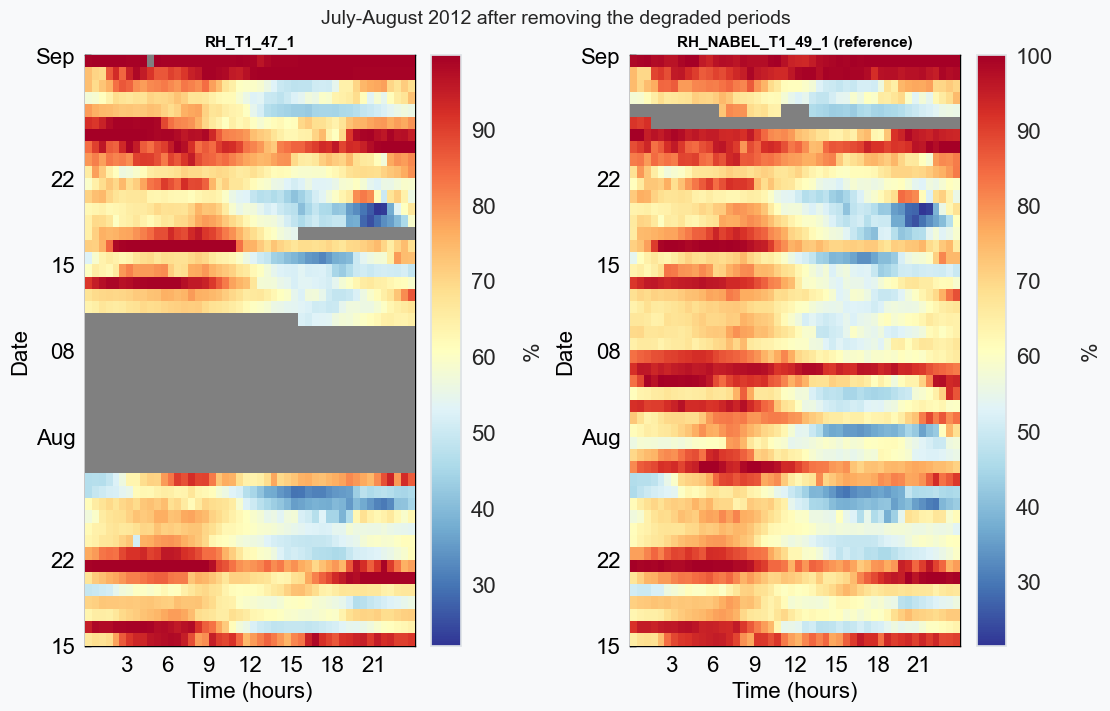

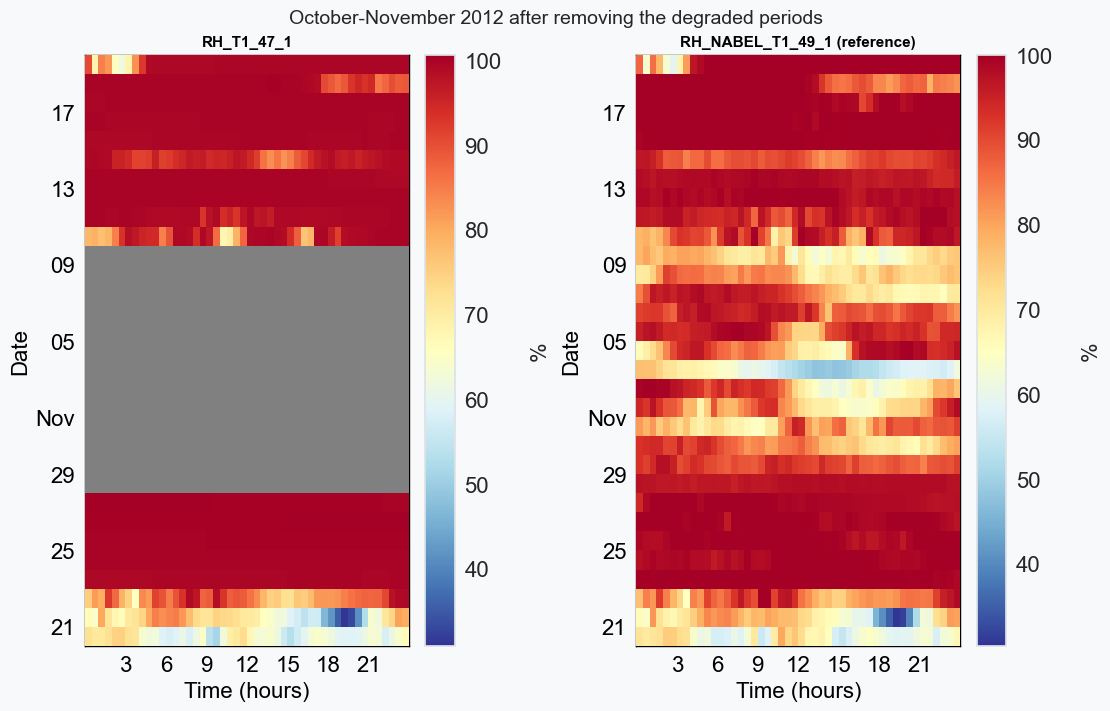

In [19]:
# Three damaged periods in 2012, all documented in the fieldbook and none repairable.
# Windows are on the CORRECTED time axis (i.e. after the +15.5 h shift above) and are identical
# to those removed in notebooks 01, 02 and 03. See the note above on where RH would differ.
BAD_WINDOWS_2012 = [
    ('2012-07-29 00:00', '2012-08-10 15:30'),  # tower power supply failure (fieldbook 09.08.2012)
    ('2012-08-17 15:30', '2012-08-18 00:00'),  # transitional tail after the last shifted value
    ('2012-10-28 00:00', '2012-11-10 00:00'),  # storm damage, stressed cables (fieldbook 01./06.11.2012)
]

# Recorded per record, not just counted: this is what separates flag 2 from flag 1 on export.
removed_here = pd.Series(False, index=rh_2004_2025.index)
_exceeded_and_removed = 0
for _start, _end in BAD_WINDOWS_2012:
    _locs = (rh_2004_2025.index >= _start) & (rh_2004_2025.index <= _end)
    _measured = _locs & rh_2004_2025[TARGET].notna()
    _exceeded_and_removed += int((rh_2004_2025.loc[_measured, TARGET] > 100).sum())
    removed_here |= _measured
    rh_2004_2025.loc[_locs, TARGET] = np.nan

print(f"Removed {int(removed_here.sum())} measured records from {TARGET}.")
print("These become gaps here; the reconstruction section below fills them from NABEL.")
print(f"Of these, {_exceeded_and_removed} read above 100% - they would otherwise have")
print(f"contributed to the offset of the RH>100% correction, which is why that step runs after this one.")

# One heatmap pair per affected period, with the NABEL sensor as the reference.
for _lo, _hi, _label in [('2012-07-15', '2012-09-01', 'July-August'),
                         ('2012-10-20', '2012-11-20', 'October-November')]:
    fig, axs = plt.subplots(ncols=2, figsize=(11, 7), dpi=100, layout="constrained")
    fig.suptitle(f'{_label} 2012 after removing the degraded periods', fontsize=14)
    _show = (rh_2004_2025.index >= _lo) & (rh_2004_2025.index <= _hi)
    dv.plotting.HeatmapDateTime(series=rh_2004_2025.loc[_show, TARGET]).plot(
        ax=axs[0], cb_digits_after_comma=0, zlabel='%',
        format_style=dv.plotting.FormatStyle(title=TARGET, title_fontsize=11))
    dv.plotting.HeatmapDateTime(series=rh_2004_2025.loc[_show, REFERENCE]).plot(
        ax=axs[1], cb_digits_after_comma=0, zlabel='%',
        format_style=dv.plotting.FormatStyle(title=f'{REFERENCE} (reference)', title_fontsize=11))

### December 2012 ventilation faults: checked, not applicable

The fieldbook records ventilation faults on the `RH`/`TA` units at **9 m and 27 m** in December
2012. The sensor exported here sits at **47 m**, on its own ventilated housing, so it should be
unaffected — but "should be" is not evidence, so the daily agreement with NABEL was compared
against the seasonal norm.

Daily RMSE between `RH_T1_47_1` and NABEL, median over all years 2004-2018, by month:

| month | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| median | 3.42 | 3.83 | 2.94 | 2.13 | 2.18 | 2.06 | 2.03 | 2.01 | 2.05 | 2.53 | 2.92 | 3.13 |

The two sensors agree to about 2 % in summer and drift apart to 3-4 % in winter. That winter
divergence is a known, unresolved property of this 47 m / 49 m pair and is **not** a fault.

December medians per year: 2010 `3.69`, 2011 `3.85`, **2012 `3.90`**, 2013 `3.53`, 2014 `3.99`,
2015 `3.93`, 2016 `7.12`, 2017 `8.72`.

December 2012 is indistinguishable from the Decembers on either side of it, and far better than
2016 and 2017. Five of its 30 days exceed the all-year December 90th percentile, which is what
chance alone produces. **No correction is applied for this**, and the December data are kept.

### `RH > 100%` correction

Relative humidity cannot physically exceed 100%. Values above it indicate sensor drift near
saturation, and `dv.corrections.remove_relativehumidity_offset` removes it: it derives a daily
offset from the records above 100%, subtracts that offset from the series, and clips whatever
still sits above 100%.

**Scope.** The library function interpolates its daily offset and then ffill/bfills it across the
entire index, so a single call on the whole record also shifts years that never exceed 100%. Over
this record that means a flat `+0.71 %` across 2004-2006 and a flat `+0.133 %` across 2016-2025 —
ten years with not one value above 100. Subtracting a measured drift from records below 100% is
the point of the correction; extrapolating it into a decade with no evidence of drift is not. So
`remove_rh_offset_by_year` (defined above) runs the correction **per exceedance year**, and years
without an exceedance come through bit-identical.

**What this correction does and does not guarantee.**

- It **does** guarantee `RH <= 100` in the years it runs in: the final clip is unconditional.
  Years it skips are guaranteed by construction, since having no value above 100 is what makes
  them skipped. The export check below asserts the bound over the whole series regardless.
- It does **not** guarantee `RH >= 0`. The offset is subtracted from every record in the year,
  including dry ones, and nothing clips the lower end. With a large offset and a genuinely dry
  record the result can go negative. It does not happen here — the offsets are at most 2.0 % and
  the driest record is far above that — but the export check asserts the lower bound rather than
  assuming it.
- It does **not** repair a saturated sensor. A drifting sensor loses resolution near 100%, and
  subtracting an offset does not bring that information back. These records are corrected, not
  restored.

**Gap safety.** The correction subtracts an offset that is defined everywhere from a series that
is not, and `NaN - x` is `NaN`, so gaps stay gaps. This was verified on the real series rather
than assumed, and the cell below re-checks it — the analogous correction in notebook `03` writes
into gaps and silently turned 7,543 fills into apparent measurements.

In [20]:
_before = rh_2004_2025[TARGET].copy()
rh_2004_2025[TARGET], _exceed_years = remove_rh_offset_by_year(rh_2004_2025[TARGET])
_after = rh_2004_2025[TARGET]

_changed = (_after - _before).abs() > 1e-9
print(f"Correction applied in years: {_exceed_years}")
print(f"Records above 100%:  before {int((_before > 100).sum()):,}   after {int((_after > 100).sum()):,}")
print(f"Records changed:     {int(_changed.sum()):,} of {int(_before.notna().sum()):,} measured")
print(f"Largest change:      {float((_after - _before).abs().max()):.2f} %")
print(f"Untouched years:     {sorted(set(range(_before.index.year.min(), _before.index.year.max() + 1)) - set(_exceed_years))}")

# Gap safety: the correction must not invent a value where there was none.
_written_into_gaps = int((_before.isna() & _after.notna()).sum())
print(f"\nValues written into gaps: {_written_into_gaps}")
assert _written_into_gaps == 0, "correction wrote into gaps - the provenance flag would be wrong"

# Per-year effect, so an unexpectedly shifted year is visible rather than buried in the total.
_eff = pd.DataFrame({
    'exceeded_100_before': (_before > 100).groupby(_before.index.year).sum(),
    'records_changed': _changed.groupby(_changed.index.year).sum(),
    'mean_change': (_before - _after).groupby(_before.index.year).mean().round(3),
    'max_change': (_before - _after).groupby(_before.index.year).max().round(2),
})
_eff

> running remove_relativehumidity_offset ...

> running remove_relativehumidity_offset ...

> running remove_relativehumidity_offset ...

> running remove_relativehumidity_offset ...

> running remove_relativehumidity_offset ...

> running remove_relativehumidity_offset ...

> running remove_relativehumidity_offset ...

Correction applied in years: [2007, 2010, 2011, 2012, 2013, 2014, 2015]
Records above 100%:  before 1,931   after 0
Records changed:     121,123 of 369,079 measured
Largest change:      2.00 %
Untouched years:     [2004, 2005, 2006, 2008, 2009, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

Values written into gaps: 0


,exceeded_100_before,records_changed,mean_change,max_change
TIMESTAMP_MIDDLE,,,,
2004,0,0,0.000,0.0
2005,0,0,0.000,0.0
2006,0,0,0.000,0.0
2007,53,17507,0.312,1.1
2008,0,0,0.000,0.0
2009,0,0,0.000,0.0
2010,132,17351,0.140,0.3
2011,416,17499,0.454,2.0
2012,131,16308,0.108,0.6


### Dataframe


In [21]:
display(rh_2004_2025)
rh_2004_2025.describe()

,RH_T1_47_1,RH_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,96.366667
2004-01-01 00:45:00,NaN,95.566667
2004-01-01 01:15:00,NaN,92.200000
2004-01-01 01:45:00,NaN,91.300000
2004-01-01 02:15:00,NaN,92.633333
...,...,...
2025-12-31 21:45:00,42.332976,NaN
2025-12-31 22:15:00,39.230344,NaN
2025-12-31 22:45:00,55.771803,NaN


,RH_T1_47_1,RH_NABEL_T1_49_1
count,369079.000000,262314.000000
mean,79.519055,76.902333
std,18.823475,18.123961
min,16.990002,13.666667
25%,65.756900,63.900000
50%,83.185047,80.100000
75%,98.244663,92.933333
max,100.000000,100.000000


::: {.callout-note title="The NABEL series is not corrected"}
`RH_NABEL_T1_49_1` never exceeds 100% anywhere in this record, so the `RH > 100%` correction would
be a no-op for it and is not applied. It is used below as the source for reconstruction, and is
not itself exported.
:::

***

## 🟩 Reconstruction from the NABEL sensor


### Why, and what this is not

`RH_T1_47_1` does not begin until **20 September 2004**, leaving an 8.7-month block at the start of
the record with no measurement at all, plus scattered gaps and the 2012 periods removed above. The
NABEL sensor at 49 m measured throughout **2004-2018** and is co-located on the same tower.

Those gaps are filled here from NABEL. This is a **transfer between two measurements of the same
quantity**, not the model-based gap-filling of notebooks `01`-`03`: no meteorological drivers, no
feature engineering, no XGBoost. A long contiguous block like the 2004 one is exactly the case a
driver-based model handles worst and a second co-located sensor handles well.

Records with no NABEL value — chiefly the post-2018 gaps — are reconstructed in a second pass
from MeteoSwiss Lägern (section below), so nothing is left as `NaN`.

### The two sensors do not differ by a constant

A straight copy of NABEL would be wrong in a way that is easy to miss. Over the 2004-2018 overlap
the 47 m sensor reads systematically **moister** than NABEL, and by an amount that varies two ways.

**Seasonally** — mean offset `47 m - NABEL`, pooled over the whole overlap:

| month | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| offset (%) | 3.21 | 3.86 | 2.96 | 2.14 | 1.54 | 0.88 | 0.50 | 0.37 | 0.54 | 1.43 | 2.31 | 2.81 |

The winter divergence is a known, unresolved property of this 47 m / 49 m pair. Critically, the
2004 block spans January to September, so it covers the worst months.

**And over time** — annual mean offset:

| year | 2004 | 2006 | 2008 | 2010 | 2012 | 2014 | 2016 | 2017 | 2018 |
|---|---|---|---|---|---|---|---|---|---|
| offset (%) | 1.52 | 0.08 | 0.85 | 1.41 | 2.25 | 3.19 | 4.31 | 5.06 | 3.51 |

The two sensors drift apart steadily. A single offset pooled over the whole overlap is therefore
dominated by the late, high-offset years and is **too large for 2004**: it would apply `+3.42 %`
to January 2004 where the local evidence says `+1.35 %`.

`monthly_offset_table` (defined above) fits the offset per month on the overlap within
`±2` calendar years of the record being reconstructed, which tracks both the seasonal shape and
the drift.

### Validation

Leave-one-year-out over the 1 January - 20 September window, i.e. exactly the calendar span that
has to be reconstructed in 2004. Each of the 14 usable overlap years is held out in turn, the
transfer is fitted on the others, and the reconstruction is scored against the measurement:

| method | pooled bias | pooled RMSE | median RMSE |
|---|---|---|---|
| straight NABEL copy | **-1.95 %** | 4.15 | 3.30 |
| offset, pooled over all overlap | -0.13 % | 3.45 | 2.72 |
| per-month linear regression | -0.13 % | 3.45 | 2.73 |
| **per-month offset, fitted ±2 years** | **-0.20 %** | **3.08** | **2.60** |

- A straight copy carries a ~2 % dry bias, concentrated in the winter months the 2004 block
  covers (January RMSE 5.26, February 6.22).
- A fitted per-month regression is indistinguishable from a per-month offset, so the extra
  slope parameter buys nothing and the simpler additive correction is used.
- Fitting locally rather than pooling is worth another ~11 % of RMSE, with the largest gains in
  the years furthest from the record mean (2017: 4.62 -> 3.65, 2018: 4.74 -> 3.37).

Residual uncertainty of a reconstructed record is therefore about **3 %** RH, against a
sensor-to-sensor agreement of about 2 % in summer. This is real and it is not negligible — a
reconstructed value is a good estimate, not a measurement, which is why it carries its own flag.

In [22]:
OFFSETS = monthly_offset_table(rh_2004_2025[TARGET], rh_2004_2025[REFERENCE])

_overlap_n = int(pd.concat([rh_2004_2025[TARGET], rh_2004_2025[REFERENCE]], axis=1).dropna().shape[0])
print(f"Offsets fitted on {_overlap_n:,} overlapping records "
      f"(+/-{OFFSET_WINDOW_YEARS} years, min {OFFSET_MIN_SAMPLES} samples per month).")

# The 2004 block is by far the largest reconstruction, so show exactly what it will receive.
print("\nOffsets applied to the 2004 block (Jan-Sep):")
display(pd.Series({m: round(OFFSETS[(2004, m)], 2) for m in range(1, 10)},
                  name='offset (%)').rename_axis('month'))

# Full table, so a drifting or fallback-filled year is visible rather than implicit.
_offset_matrix = OFFSETS.unstack()
_offset_matrix.index.name = 'year'
_offset_matrix.columns.name = 'month'
_offset_matrix.round(2)

Offsets fitted on 246,585 overlapping records (+/-2 years, min 500 samples per month).

Offsets applied to the 2004 block (Jan-Sep):


month
1    1.35
2    2.13
3    2.03
4    1.24
5    0.40
6   -0.32
7   -0.86
8   -0.38
9   -1.02
Name: offset (%), dtype: float64

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2004,1.35,2.13,2.03,1.24,0.40,-0.32,-0.86,-0.38,-1.02,-0.19,0.71,1.65
2005,1.06,1.57,1.76,0.66,0.21,-0.46,-0.88,-0.55,-0.99,-0.25,0.90,1.58
2006,1.22,1.69,1.89,0.84,0.29,-0.46,-0.84,-0.65,-0.78,-0.07,1.09,1.68
2007,1.37,1.85,2.01,0.86,0.23,-0.42,-0.84,-0.68,-0.85,-0.03,1.16,1.65
2008,1.51,1.60,1.99,0.74,0.32,-0.53,-0.95,-0.72,-0.53,0.38,1.64,2.02
2009,1.66,1.68,1.92,0.75,0.39,-0.27,-0.62,-0.61,-0.29,0.79,1.98,2.41
2010,2.16,3.01,1.99,1.29,0.61,-0.07,-0.44,-0.53,-0.04,0.99,2.14,2.98
2011,2.45,3.36,2.18,1.55,0.94,0.18,-0.37,-0.35,0.19,1.21,2.25,3.04
2012,2.96,3.78,2.24,1.94,1.53,0.37,0.42,0.20,0.73,1.82,2.60,3.26


In [23]:
_before_recon = rh_2004_2025[TARGET].copy()
rh_2004_2025[TARGET], reconstructed = reconstruct_from_reference(
    rh_2004_2025[TARGET], rh_2004_2025[REFERENCE], OFFSETS)

print(f"Reconstructed {int(reconstructed.sum()):,} records from {REFERENCE}")
print(f"  previously never measured: {int((reconstructed & never_measured).sum()):,}")
print(f"  previously removed here:   {int((reconstructed & removed_here).sum()):,}")
print(f"Still missing:  {int(rh_2004_2025[TARGET].isna().sum()):,} "
      f"(no NABEL value available)")

# Reconstruction must not touch a record that already had a value.
assert rh_2004_2025.loc[_before_recon.notna(), TARGET].equals(_before_recon.dropna()), \
    "reconstruction overwrote measured values"
print("\nMeasured records untouched by the reconstruction.")

# Reconstructed values must respect the physical bounds.
_rec = rh_2004_2025.loc[reconstructed, TARGET]
print(f"Reconstructed range: {_rec.min():.2f} - {_rec.max():.2f} %")

Reconstructed 15,729 records from RH_NABEL_T1_49_1
  previously never measured: 14,514
  previously removed here:   1,215
Still missing:  920 (no NABEL value available)

Measured records untouched by the reconstruction.
Reconstructed range: 22.65 - 100.00 %


### Does the reconstructed 2004 block look like a plausible year?

The reconstruction cannot be validated against the 47 m sensor in 2004, since there is nothing to
validate against — that is the whole reason it exists. What can be checked is whether the result
is climatologically sensible: its monthly means should sit near the same months in the following
measured years, differing only by ordinary interannual variability, and its diurnal structure
should look like an `RH` year rather than a flat or clipped series.

,2004 (reconstructed),2005-2008 (measured),difference
month,,,
1,89.5,84.6,4.9
2,74.7,82.5,-7.8
3,74.3,78.8,-4.5
4,66.7,69.7,-3.0
5,67.4,69.8,-2.4
6,70.1,69.6,0.5
7,69.4,68.9,0.5
8,74.3,77.9,-3.6
9,68.5,79.2,-10.7


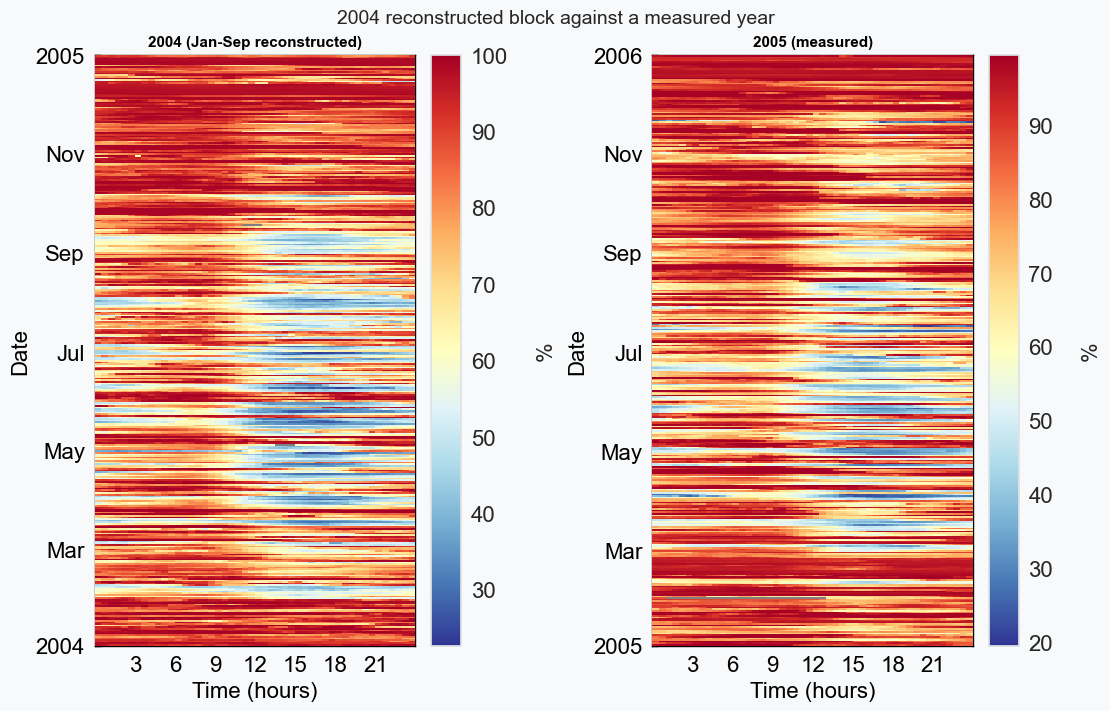

In [24]:
_recon_2004 = rh_2004_2025.loc['2004-01-01':'2004-09-20', TARGET]
_measured_ref = rh_2004_2025.loc['2005':'2008', TARGET]
_measured_ref = _measured_ref[_measured_ref.index.month <= 9]

_cmp = pd.DataFrame({
    '2004 (reconstructed)': _recon_2004.groupby(_recon_2004.index.month).mean().round(1),
    '2005-2008 (measured)': _measured_ref.groupby(_measured_ref.index.month).mean().round(1),
})
_cmp['difference'] = (_cmp.iloc[:, 0] - _cmp.iloc[:, 1]).round(1)
_cmp.index.name = 'month'
display(_cmp)

fig, axs = plt.subplots(ncols=2, figsize=(11, 7), dpi=100, layout="constrained")
fig.suptitle('2004 reconstructed block against a measured year', fontsize=14)
dv.plotting.HeatmapDateTime(series=rh_2004_2025.loc['2004', TARGET]).plot(
    ax=axs[0], cb_digits_after_comma=0, zlabel='%',
    format_style=dv.plotting.FormatStyle(title='2004 (Jan-Sep reconstructed)', title_fontsize=11))
dv.plotting.HeatmapDateTime(series=rh_2004_2025.loc['2005', TARGET]).plot(
    ax=axs[1], cb_digits_after_comma=0, zlabel='%',
    format_style=dv.plotting.FormatStyle(title='2005 (measured)', title_fontsize=11))

## 🟩 Second reconstruction pass: MeteoSwiss Lägern

NABEL ends in 2018, leaving ~920 gaps the pass above cannot reach — almost all after 2018. The
MeteoSwiss Lägern station (`RH_LAE_MS`, 2.5 km away, 845 m) measures `RH` over the whole 2004-2025
record and covers **100%** of those remaining gaps. A second pass fills them the same way the NABEL
pass does: an additive per-month offset fitted on the tower-vs-Lägern overlap, then applied to the
Lägern value.

Lägern is a weaker reference than NABEL — 2.5 km away and 400 m lower, against NABEL's 49 m on the
same tower. Over the 2004-2025 overlap tower `RH` and Lägern correlate `r = 0.94` with a mean bias
of `+0.09 %`, and the monthly offset drifts seasonally over roughly `-1.3 %` to `+2.7 %` — smaller
than the NABEL drift but real, which is why the same month-by-month offset is used rather than a
straight copy. These fills carry flag `4`, kept distinct from NABEL's flag `3` so their larger
uncertainty stays visible.


### Load the reference and check its alignment

`RH_LAE_MS` carries `TIMESTAMP_END`; this notebook works on `TIMESTAMP_MID`, so its index is shifted
back 15 minutes (the midpoint of a 30MIN bin). The guard correlates it against the **measured** tower
`RH` (flag-0 records only, never the NABEL-reconstructed ones) at offsets `-1/0/+1` and asserts
offset `0` wins — a mis-shifted reference would fit the wrong daily cycle with nothing in the output
to show it. `RH` has a clear diurnal cycle, so no daytime filter is needed; all overlapping records
are used.


In [25]:
rh_ref = pd.read_parquet(REFPATH)[[REFCOL]]
rh_ref.index = rh_ref.index - pd.Timedelta(minutes=15)  # TIMESTAMP_END -> TIMESTAMP_MID
rh_ref.index.name = rh_2004_2025.index.name
lae = rh_ref[REFCOL].reindex(rh_2004_2025.index)

# Measured tower RH only: exclude the NABEL-reconstructed records so neither the alignment guard
# nor the offset fit below ever sees a reconstructed value.
measured_rh = rh_2004_2025[TARGET].where(~reconstructed)

_scores = {}
for _off in (-1, 0, 1):
    _j = pd.concat([measured_rh.rename('t'), lae.shift(_off).rename('r')], axis=1).dropna()
    _scores[_off] = _j['t'].corr(_j['r'])
    print(f"  offset {_off:+d} x 30min: corr {_scores[_off]:.4f}")
assert max(_scores, key=_scores.get) == 0, f"reference is mis-aligned: {_scores}"
print("OK: offset 0 wins, the TIMESTAMP_MID conversion is correct.")

_still_missing = rh_2004_2025[TARGET].isna()
print(f"\n{REFCOL} available for {lae.notna().mean() * 100:.2f}% of all records")
print(f"Laegern covers {int((lae.notna() & _still_missing).sum()):,} of "
      f"{int(_still_missing.sum()):,} records still missing after the NABEL pass")


  offset -1 x 30min: corr 0.9363
  offset +0 x 30min: corr 0.9421
  offset +1 x 30min: corr 0.9340
OK: offset 0 wins, the TIMESTAMP_MID conversion is correct.

RH_LAE_MS available for 99.53% of all records
Laegern covers 920 of 920 records still missing after the NABEL pass


### Fit the offset and reconstruct

The offset table is fitted on the tower-vs-Lägern overlap using only **measured** tower records
(`measured_rh`), with the same `monthly_offset_table` helper and the same `±2 years` / `500 samples`
settings as the NABEL pass. `reconstruct_from_reference` then fills only the records still missing
after the NABEL pass, clips to `[0, 100]`, and cannot touch a record that already carries a value.


In [26]:
OFFSETS_LAE = monthly_offset_table(measured_rh, lae)

_overlap_n = int(pd.concat([measured_rh, lae], axis=1).dropna().shape[0])
print(f"Laegern offsets fitted on {_overlap_n:,} overlapping measured records "
      f"(+/-{OFFSET_WINDOW_YEARS} years, min {OFFSET_MIN_SAMPLES} samples per month).")
print(f"Fitted monthly offset range: {OFFSETS_LAE.min():+.2f} .. {OFFSETS_LAE.max():+.2f} %")

_before_recon_lae = rh_2004_2025[TARGET].copy()
rh_2004_2025[TARGET], reconstructed_lae = reconstruct_from_reference(
    rh_2004_2025[TARGET], lae, OFFSETS_LAE)

print(f"\nReconstructed {int(reconstructed_lae.sum()):,} records from {REFCOL}")
print(f"  previously never measured: {int((reconstructed_lae & never_measured).sum()):,}")
print(f"  previously removed here:   {int((reconstructed_lae & removed_here).sum()):,}")

# The Laegern pass may only fill records that were still missing: it must not overwrite a measured
# or a NABEL-reconstructed value, and must not overlap the NABEL mask.
assert rh_2004_2025.loc[_before_recon_lae.notna(), TARGET].equals(_before_recon_lae.dropna()), \
    "Laegern reconstruction overwrote an existing value"
assert int((reconstructed_lae & reconstructed).sum()) == 0, "Laegern overlaps the NABEL reconstruction"
print("Existing measured and NABEL-reconstructed records untouched by the Laegern pass.")

# Reconstructed values must respect the physical bounds.
_rec_lae = rh_2004_2025.loc[reconstructed_lae, TARGET]
print(f"Laegern-reconstructed range: {_rec_lae.min():.2f} - {_rec_lae.max():.2f} %")
assert _rec_lae.between(0, 100).all(), "Laegern reconstruction produced out-of-range RH"

# Both passes together must leave no gap.
_residual = int(rh_2004_2025[TARGET].isna().sum())
print(f"\nStill missing after both passes: {_residual}")
assert _residual == 0, "product still has gaps after the Laegern pass"
print("Product is complete: every record carries a value.")


Laegern offsets fitted on 368,813 overlapping measured records (+/-2 years, min 500 samples per month).
Fitted monthly offset range: -3.91 .. +6.16 %

Reconstructed 920 records from RH_LAE_MS
  previously never measured: 920
  previously removed here:   0
Existing measured and NABEL-reconstructed records untouched by the Laegern pass.
Laegern-reconstructed range: 39.82 - 100.00 %

Still missing after both passes: 0
Product is complete: every record carries a value.


***

## ➡️ Prepare dataframe for export

The provenance flag is assembled from the masks captured along the way: `never_measured` (taken
before anything was removed), `removed_here` (the 2012 windows), `reconstructed` (NABEL) and
`reconstructed_lae` (Lägern). Order matters — the two reconstruction masks are applied after `1`
and `2`, because a record that was removed here and then reconstructed carries a value and must
read `3` or `4`, not `2`.

Codes `1` and `2` would survive only where neither reference could supply a value. Lägern covers
every gap NABEL missed, so in this record they do not occur at all.


In [27]:
VALCOL = TARGET
FLAGCOL = f"FLAG_{TARGET}_MISSING"

flag = pd.Series(0, index=rh_2004_2025.index, dtype=int, name=FLAGCOL)
flag[never_measured] = 1
flag[removed_here] = 2
flag[reconstructed] = 3       # NABEL pass
flag[reconstructed_lae] = 4   # Laegern pass; both reconstruction masks are applied after 1/2, so a
                              # reconstructed record reads 3 or 4, never 1 or 2

export_df = pd.concat([rh_2004_2025[VALCOL], flag], axis=1)
export_df

,RH_T1_47_1,FLAG_RH_T1_47_1_MISSING
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,97.718962,3
2004-01-01 00:45:00,96.918962,3
2004-01-01 01:15:00,93.552296,3
2004-01-01 01:45:00,92.652296,3
2004-01-01 02:15:00,93.985629,3
...,...,...
2025-12-31 21:45:00,42.332976,0
2025-12-31 22:15:00,39.230344,0
2025-12-31 22:45:00,55.771803,0


Sanity check. The exported series is now **complete** — both reconstruction passes together leave
no gap — so the checks match the completeness of notebooks `01`-`03`, with `RH`-specific bounds:

- the index must be continuous 30MIN with no duplicates, every record must carry a flag, and no
  value may be missing
- the flag must agree with the values exactly: a value is present if and only if the flag is in
  `PRESENT_FLAGS` (`0`, `3` or `4`) — which, with no gaps, is every record
- `RH` is bounded `[0, 100]`, and both ends are asserted rather than assumed (the `RH > 100%`
  correction clips the upper end; reconstruction adds an offset and clips both)


In [28]:
print(f"Records:         {len(export_df):,}")
print(f"Values present:  {export_df[VALCOL].notna().sum():,}")
print(f"Missing values:  {export_df[VALCOL].isnull().sum():,}")
print(f"Missing flags:   {export_df[FLAGCOL].isnull().sum()}")
print(f"Duplicate index: {export_df.index.duplicated().sum()}")
print(f"Index gaps:      {(export_df.index.to_series().diff().dropna() != pd.Timedelta('30min')).sum()}")
print(f"Min / max:       {export_df[VALCOL].min():.2f} / {export_df[VALCOL].max():.2f} %")

# The flag has to describe the value column exactly, otherwise a downstream consumer would be
# working from a wrong provenance.
_agree = (export_df[VALCOL].notna() == export_df[FLAGCOL].isin(PRESENT_FLAGS)).all()
print(f"\nFlag agrees with values: {bool(_agree)}")
assert _agree, "flag and value column disagree about which records carry a value"

# RH is bounded. The correction clips the upper end, reconstruction clips both; nothing else does.
assert export_df[VALCOL].min() >= 0, "RH below 0%"
assert export_df[VALCOL].max() <= 100, "RH above 100%"
print("Bounds [0, 100] hold.")

# The product is complete: both reconstruction passes together leave no gap.
assert export_df[VALCOL].isna().sum() == 0, "product is not complete"
print("Complete: no missing values.")

print("\nProvenance:")
_counts = export_df[FLAGCOL].value_counts().sort_index()
display(pd.DataFrame({'count': _counts}).rename(index=FLAG_LEGEND))

export_df.describe()

Records:         385,728
Values present:  385,728
Missing values:  0
Missing flags:   0
Duplicate index: 0
Index gaps:      0
Min / max:       16.99 / 100.00 %

Flag agrees with values: True
Bounds [0, 100] hold.
Complete: no missing values.

Provenance:


,count
FLAG_RH_T1_47_1_MISSING,
0 = measured at 47 m (corrected),369079
3 = reconstructed from NABEL at 49 m,15729
4 = reconstructed from MeteoSwiss Lägern at 2.5 km,920


,RH_T1_47_1,FLAG_RH_T1_47_1_MISSING
count,385728.000000,385728.000000
mean,79.350576,0.131873
std,18.837149,0.622711
min,16.990002,0.000000
25%,65.511392,0.000000
50%,82.910598,0.000000
75%,98.056818,0.000000
max,100.000000,4.000000


### Per-year coverage

Records per year by provenance. The product is now complete, so this shows *how* each year is
filled rather than counting gaps:

- `RH_T1_47_1` was **not measured before 20 September 2004**, so almost all of 2004 is
  reconstructed rather than measured — the first year is short on measurements by design, not by
  data loss.
- The reconstruction source switches at the end of **2018**: NABEL (flag `3`) up to there,
  MeteoSwiss Lägern (flag `4`) for the gaps after it.
- Code `2` (removed here) does not appear: NABEL covers all three 2012 windows, so those 1,215
  records were reconstructed and read `3`. The distinction is preserved inside the notebook in
  `removed_here` and reported by the reconstruction cell above.


,records,0 = measured at 47 m (corrected),3 = reconstructed from NABEL at 49 m,4 = reconstructed from MeteoSwiss Lägern at 2.5 km
year,,,,
2004,17568,4922,12640,6
2005,17520,17486,10,24
2006,17520,17493,27,0
2007,17520,17507,13,0
2008,17568,17548,20,0
2009,17520,17034,486,0
2010,17520,17351,169,0
2011,17520,17499,11,10
2012,17568,16308,1260,0


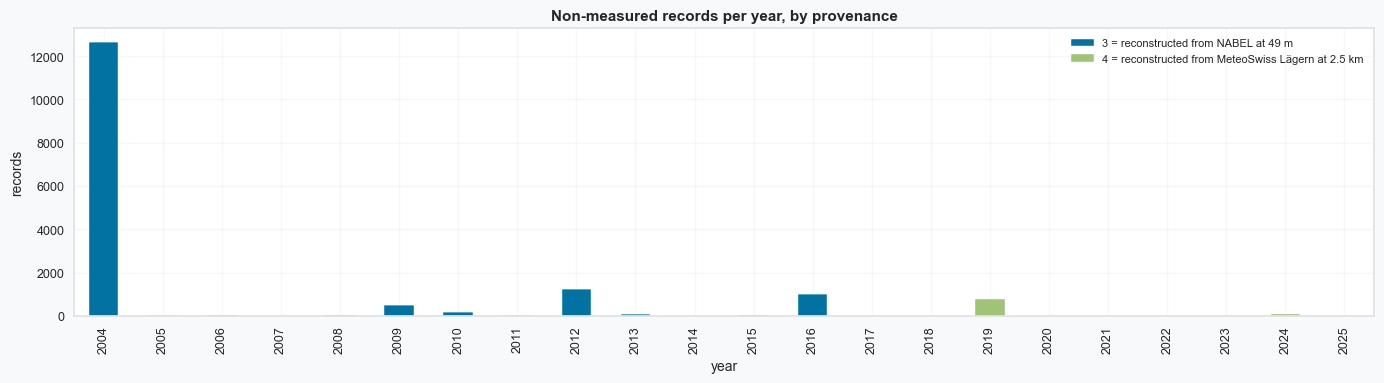

In [29]:
coverage_stats_by_year(export_df[VALCOL], export_df[FLAGCOL])

### Plots

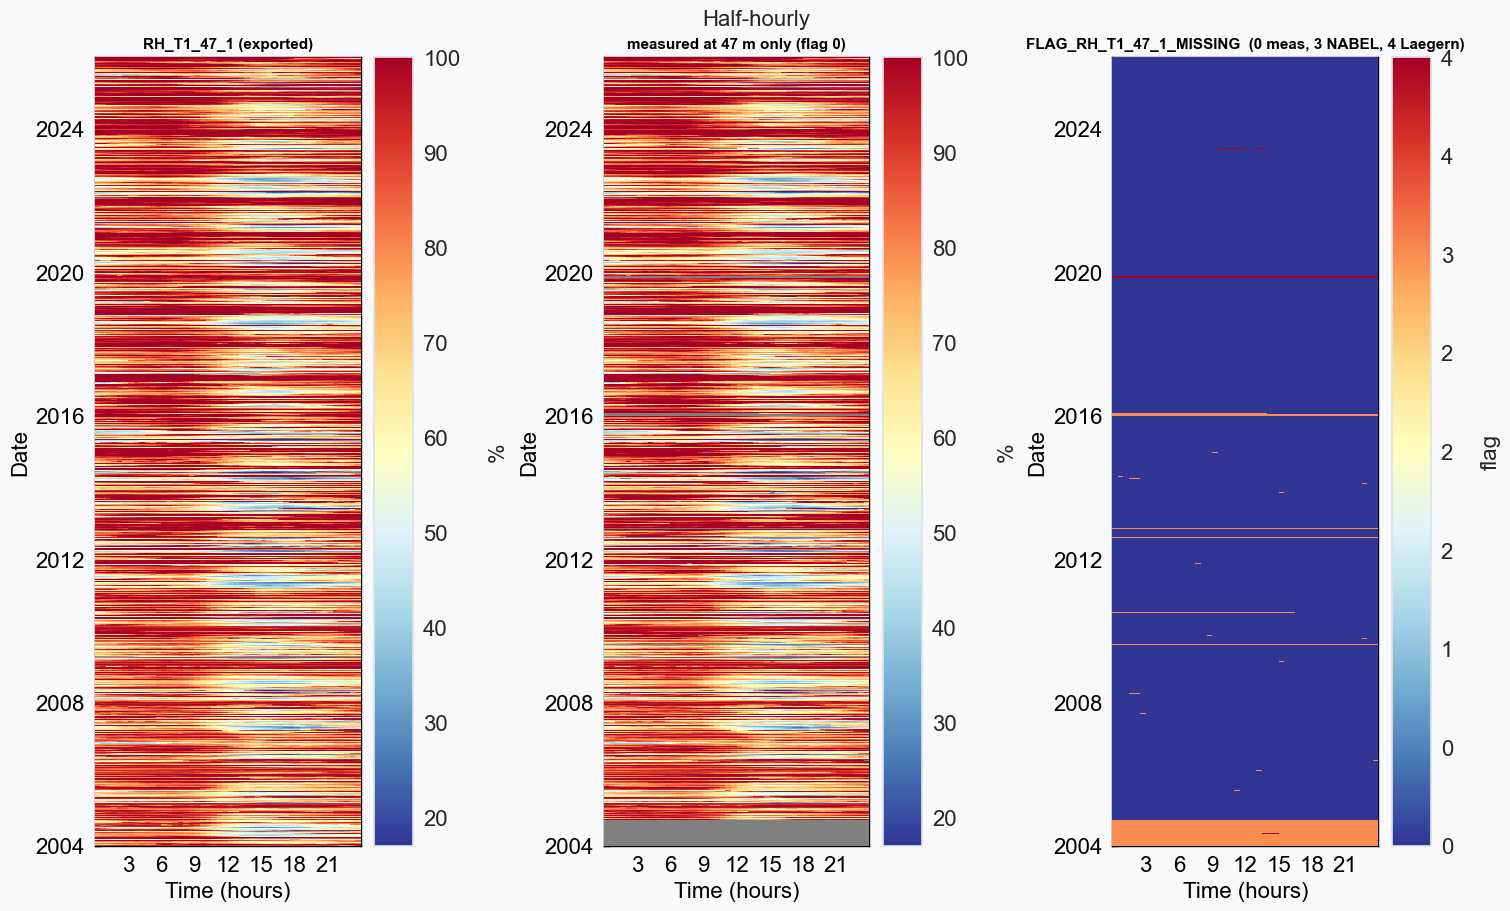

In [30]:
fig, axs = plt.subplots(ncols=3, figsize=(15, 9), dpi=100, layout="constrained")
fig.suptitle('Half-hourly', fontsize=16)
dv.plotting.HeatmapDateTime(series=export_df[VALCOL]).plot(
    ax=axs[0], cb_digits_after_comma=0, zlabel='%',
    format_style=dv.plotting.FormatStyle(title=f'{VALCOL} (exported)', title_fontsize=11))
dv.plotting.HeatmapDateTime(series=export_df[VALCOL].where(export_df[FLAGCOL] == 0)).plot(
    ax=axs[1], cb_digits_after_comma=0, zlabel='%',
    format_style=dv.plotting.FormatStyle(title='measured at 47 m only (flag 0)', title_fontsize=11))
dv.plotting.HeatmapDateTime(series=export_df[FLAGCOL].astype(float)).plot(
    ax=axs[2], cb_digits_after_comma=0, zlabel='flag',
    format_style=dv.plotting.FormatStyle(title=f'{FLAGCOL}  (0 meas, 3 NABEL, 4 Laegern)',
                                         title_fontsize=11))

array([<Axes: xlabel='TIMESTAMP_MIDDLE', ylabel='RH (%)'>,
       <Axes: xlabel='TIMESTAMP_MIDDLE', ylabel='RH (%)'>,
       <Axes: xlabel='TIMESTAMP_MIDDLE', ylabel='RH (%)'>,
       <Axes: xlabel='TIMESTAMP_MIDDLE', ylabel='RH (%)'>,
       <Axes: xlabel='TIMESTAMP_MIDDLE', ylabel='flag'>], dtype=object)

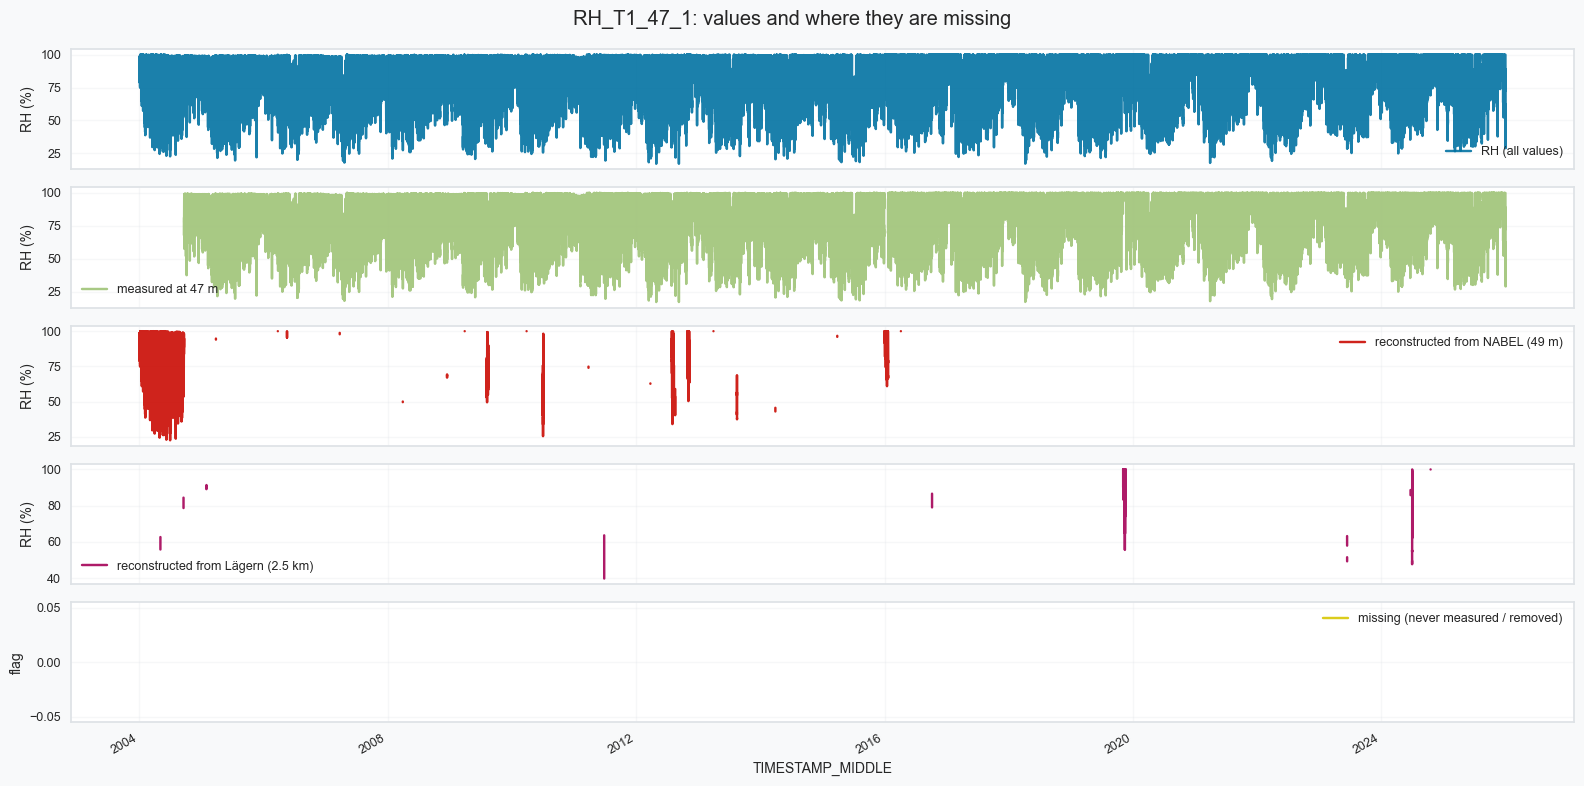

In [31]:
plot_presence_panels(export_df[VALCOL], export_df[FLAGCOL],
                     title=f'{VALCOL}: values and where they are missing')

***

## 💾 Save to file

In [32]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\04_METEO_RH_CORRECTED_2004-2025.parquet (0.067 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS\04_METEO_RH_CORRECTED_2004-2025.parquet


Read the written file back and check it against the frame in memory, rather than trusting that
the save worked. Reading the parquet is the same operation the downstream notebooks perform.

In [33]:
_check = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{OUTNAME}.parquet"))
print(f"Columns:      {list(_check.columns)}")
print(f"Records:      {len(_check):,}")
print(f"Range:        {_check.index[0]} -> {_check.index[-1]}")
print(f"Index name:   {_check.index.name}")
print(f"Missing:      {_check[VALCOL].isna().sum():,}")
print(f"Min / max:    {_check[VALCOL].min():.2f} / {_check[VALCOL].max():.2f} %")
print(f"Flag counts:  {_check[FLAGCOL].value_counts().sort_index().to_dict()}")

assert _check[VALCOL].equals(export_df[VALCOL]), "values differ from what was written"
assert _check[FLAGCOL].equals(export_df[FLAGCOL]), "flags differ from what was written"
assert (_check[VALCOL].notna() == _check[FLAGCOL].isin(PRESENT_FLAGS)).all(), "flag/value disagreement in written file"
print("\nWritten file matches the exported dataframe.")

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\04_METEO_RH_CORRECTED_2004-2025.parquet (0.014 seconds).

Columns:      ['RH_T1_47_1', 'FLAG_RH_T1_47_1_MISSING']
Records:      385,728
Range:        2004-01-01 00:15:00 -> 2025-12-31 23:45:00
Index name:   TIMESTAMP_MIDDLE
Missing:      0
Min / max:    16.99 / 100.00 %
Flag counts:  {0: 369079, 3: 15729, 4: 920}

Written file matches the exported dataframe.


***

## ⚠️ Note for downstream notebooks

This product is now **complete**: `RH_T1_47_1` has no gaps. Earlier versions left ~920 post-2018
records as `NaN`; they are now reconstructed from MeteoSwiss Lägern, so a consumer no longer has to
cope with missing `RH`.

`FLAG_RH_T1_47_1_MISSING` tells a consumer what each record is:

- `0` — measured at 47 m and corrected. The only genuine measurements of this sensor.
- `3` — reconstructed from the NABEL sensor at 49 m on the same tower. A good estimate carrying
  about **3 % RH** of uncertainty (see the validation table), not a measurement.
- `4` — reconstructed from MeteoSwiss Lägern, 2.5 km away and 400 m lower. **New in this version.**
  Same additive-offset method as flag `3`, but a more distant, less similar sensor, so a weaker
  reconstruction with larger uncertainty. Almost all post-2018.
- `1` / `2` — retained in the legend but no longer occur: Lägern covers every gap NABEL missed.

Anything estimating measurement uncertainty, or fitting a relationship where `RH` is the
independent variable, should consider excluding flags `3` and `4` — and treating `4` as the weaker
of the two.

::: {.callout-important title="Notebook 07 must learn flag 4"}
**Notebook `07` computes VPD from `TA` and `RH`** and reads `FLAG_RH_T1_47_1_MISSING`. It currently
recognises only flag `3` (`RH_FLAG_RECONSTRUCTED = 3`, mapped to VPD flag `6`) and does **not** yet
handle flag `4`. Until `07` is updated to treat flag `4` in its own pass, a Lägern-reconstructed
`RH` would reach VPD without its own provenance. This notebook does **not** edit `07`; the coupling
is recorded here so `07` can be updated separately.
:::

`TA` arrives from notebook `02` complete and `RH` now arrives from here complete, so the VPD in
`07` no longer inherits gaps from `RH`. (Notebook `13` was the earlier VPD approach and is retired.)


## End of notebook.


In [34]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-07-21 00:55:52
Finished: 2026-07-21 00:56:30
Runtime:  00:00:38 (hh:mm:ss)
